# Etape 1 - EDA complete
**Projet : Detection d'intrusions Cloud - CSE-CIC-IDS2018**

Fichiers utilises : DDoS (mardi 20/02) + Bruteforce (mercredi 14/02)

Ce notebook fait toute l'exploration de donnees (EDA) :
1. Chargement fichier par fichier
2. Fusion en un seul dataset
3. Nettoyage
4. Analyse univariee
5. Analyse des correlations
6. Detection des outliers
7. Visualisations
8. Sauvegarde du dataset nettoye

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

PATH_DDOS = "DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet"
PATH_BF   = "Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet"
OUTPUT_DIR = "."


## 1. Chargement fichier par fichier
On charge chaque fichier separement d'abord, pour verifier sa structure avant de fusionner.

In [29]:
df_ddos = pd.read_parquet(PATH_DDOS)
df_bf = pd.read_parquet(PATH_BF)

print(f"DDoS       : {df_ddos.shape[0]} lignes, {df_ddos.shape[1]} colonnes")
print(f"Bruteforce : {df_bf.shape[0]} lignes, {df_bf.shape[1]} colonnes")
print("\nClasses DDoS       :", dict(df_ddos['Label'].value_counts()))
print("Classes Bruteforce :", dict(df_bf['Label'].value_counts()))


DDoS       : 954846 lignes, 78 colonnes
Bruteforce : 619346 lignes, 78 colonnes

Classes DDoS       : {'DDoS attacks-LOIC-HTTP': np.int64(575364), 'Benign': np.int64(379482)}
Classes Bruteforce : {'Benign': np.int64(525245), 'SSH-Bruteforce': np.int64(94048), 'FTP-BruteForce': np.int64(53)}


In [15]:
df_ddos = pd.read_parquet(PATH_DDOS)
df_bf = pd.read_parquet(PATH_BF)

# Informations générales
print("="*60)
print("DATASET DDoS")
print("="*60)
print(f"Lignes   : {df_ddos.shape[0]}")
print(f"Colonnes : {df_ddos.shape[1]}")

print("\nRépartition des labels :")
print(df_ddos['Label'].value_counts())

print("\nValeurs manquantes :")
print(df_ddos.isnull().sum().sum())

print("\nTypes des colonnes :")
print(df_ddos.dtypes)

print("\nStatistiques descriptives :")
print(df_ddos.describe())


print("\n\n" + "="*60)
print("DATASET BRUTEFORCE")
print("="*60)
print(f"Lignes   : {df_bf.shape[0]}")
print(f"Colonnes : {df_bf.shape[1]}")

print("\nRépartition des labels :")
print(df_bf['Label'].value_counts())

print("\nValeurs manquantes :")
print(df_bf.isnull().sum().sum())

print("\nTypes des colonnes :")
print(df_bf.dtypes)

print("\nStatistiques descriptives :")
print(df_bf.describe())

DATASET DDoS
Lignes   : 954846
Colonnes : 78

Répartition des labels :
Label
DDoS attacks-LOIC-HTTP    575364
Benign                    379482
Name: count, dtype: int64

Valeurs manquantes :
0

Types des colonnes :
Protocol                        int8
Flow Duration                  int32
Total Fwd Packets              int32
Total Backward Packets         int16
Fwd Packets Length Total       int32
                              ...   
Idle Mean                    float32
Idle Std                     float32
Idle Max                       int32
Idle Min                       int32
Label                       category
Length: 78, dtype: object

Statistiques descriptives :
            Protocol  Flow Duration  Total Fwd Packets  \
count  954846.000000   9.548460e+05      954846.000000   
mean        7.338671   1.396088e+07          97.906874   
std         3.712608   2.573701e+07        3585.697031   
min         0.000000   1.000000e+00           1.000000   
25%         6.000000   8.719358e+

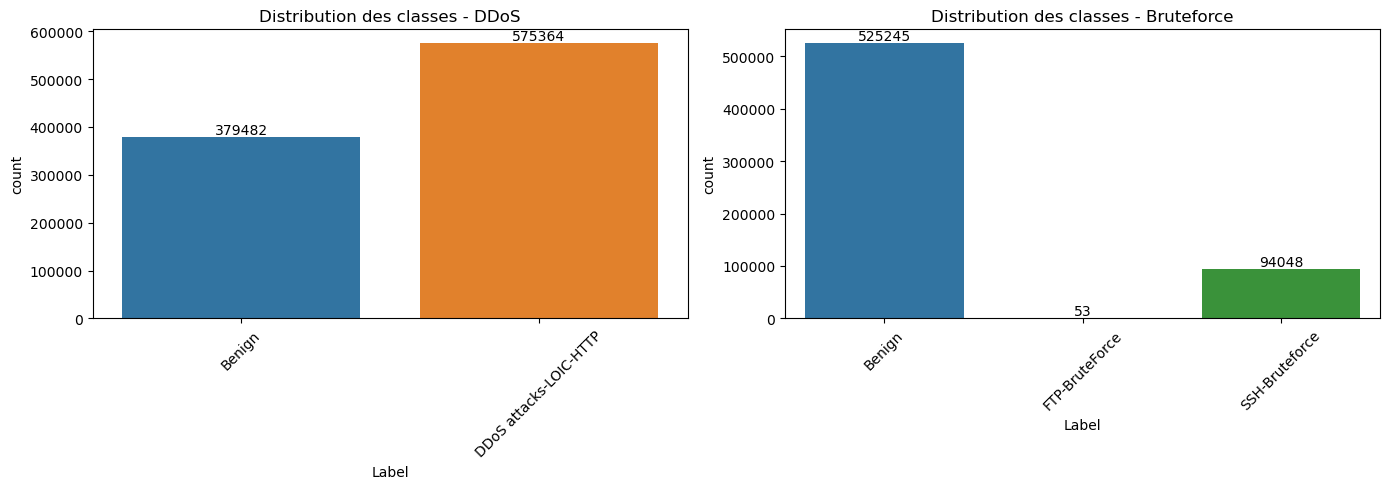

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_ddos, x='Label', hue='Label', legend=False, ax=axes[0])
axes[0].set_title("Distribution des classes - DDoS")
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container)

sns.countplot(data=df_bf, x='Label', hue='Label', legend=False, ax=axes[1])
axes[1].set_title("Distribution des classes - Bruteforce")
axes[1].tick_params(axis='x', rotation=45)

for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

## 2. Fusion des deux fichiers
On combine les deux fichiers en un seul dataset multi-classe.

In [30]:
df = pd.concat([df_ddos, df_bf], ignore_index=True)
df['Label'] = df['Label'].astype(str)
del df_ddos, df_bf

print(f"Dataset fusionne : {df.shape[0]} lignes, {df.shape[1]} colonnes")
classes = df['Label'].value_counts()
print(classes)
df.head()

Dataset fusionne : 1574192 lignes, 78 colonnes
Label
Benign                    904727
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
FTP-BruteForce                53
Name: count, dtype: int64


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,888751,11,11,1249,1969,736,0,113.545456,220.896072,976,0,179.0,364.186493,3620.811678,24.753840,4.232148e+04,47851.734375,101609,14,888751,8.887510e+04,49295.734375,140273,14,788197,78819.703125,55863.1875,139285,72,0,0,0,0,360,360,12.376920,12.37692,0,976,139.91304,290.633942,84468.085938,0,0,0,1,0,0,0,0,1,146.27272,113.545456,179.0,0,0,0,0,0,0,11,1249,11,1969,14600,233,7,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1,0,112642816,3,0,0,0,0,0,0.000000,0.000000,0,0,0.0,0.000000,0.000000,0.026633,5.630000e+07,7.071068,56300000,56300000,113000000,5.630000e+07,7.071068,56300000,56300000,0,0.000000,0.0000,0,0,0,0,0,0,0,0,0.026633,0.00000,0,0,0.00000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.00000,0.000000,0.0,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56300000.0,7.071068,56300000,56300000,Benign
2,0,112642712,3,0,0,0,0,0,0.000000,0.000000,0,0,0.0,0.000000,0.000000,0.026633,5.630000e+07,18.384777,56300000,56300000,113000000,5.630000e+07,18.384777,56300000,56300000,0,0.000000,0.0000,0,0,0,0,0,0,0,0,0.026633,0.00000,0,0,0.00000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.00000,0.000000,0.0,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56300000.0,18.384777,56300000,56300000,Benign
3,0,112642648,3,0,0,0,0,0,0.000000,0.000000,0,0,0.0,0.000000,0.000000,0.026633,5.630000e+07,5.656854,56300000,56300000,113000000,5.630000e+07,5.656854,56300000,56300000,0,0.000000,0.0000,0,0,0,0,0,0,0,0,0.026633,0.00000,0,0,0.00000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.00000,0.000000,0.0,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56300000.0,5.656854,56300000,56300000,Benign
4,0,112642702,3,0,0,0,0,0,0.000000,0.000000,0,0,0.0,0.000000,0.000000,0.026633,5.630000e+07,65.053825,56300000,56300000,113000000,5.630000e+07,65.053825,56300000,56300000,0,0.000000,0.0000,0,0,0,0,0,0,0,0,0.026633,0.00000,0,0,0.00000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.00000,0.000000,0.0,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56300000.0,65.053825,56300000,56300000,Benign


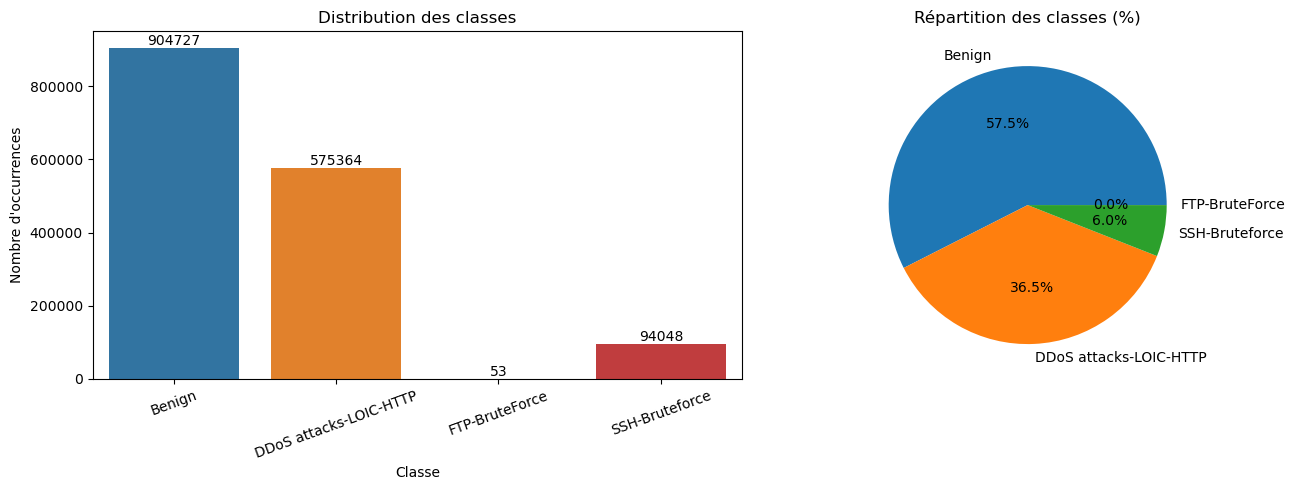

In [32]:
# Distribution des classes
classes = df['Label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Bar Chart =====
ax = sns.countplot(
    data=df,
    x='Label',
    hue='Label',
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Distribution des classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre d'occurrences")
axes[0].tick_params(axis='x', rotation=20)

for container in ax.containers:
    ax.bar_label(container)

# ===== Pie Chart =====
classes.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1]
)

axes[1].set_title("Répartition des classes (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Nettoyage
- Suppression des colonnes constantes (aucune information)
- Verification NaN / Inf
- Suppression des valeurs physiquement impossibles (duree de flux negative)
- Suppression des doublons exacts

In [34]:
num_cols = df.select_dtypes(include=[np.number]).columns

# 3a. Colonnes constantes
const_cols = [c for c in num_cols if df[c].nunique() <= 1]
df = df.drop(columns=const_cols)
num_cols = [c for c in num_cols if c not in const_cols]
print(f"Colonnes constantes supprimees ({len(const_cols)}) :")
print(const_cols)


Colonnes constantes supprimees (10) :
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


---
Les colonnes numériques ont été identifiées puis analysées afin de détecter les colonnes constantes. Une colonne constante contient une seule valeur pour toutes les observations et n'apporte aucune information discriminante pour la classification. Ces colonnes ont été supprimées afin de réduire la dimension des données et d'améliorer l'efficacité des modèles d'apprentissage automatique.

In [35]:
# 3b. NaN / Inf
nan_total = int(df.isna().sum().sum())
inf_total = int(((df[num_cols] == np.inf) | (df[num_cols] == -np.inf)).sum().sum())
print(f"NaN totaux : {nan_total} | Inf totaux : {inf_total}")

if nan_total > 0:
    df = df.dropna()
    print(f"-> {nan_total} valeurs NaN supprimees")
if inf_total > 0:
    mask_inf = (df[num_cols] == np.inf) | (df[num_cols] == -np.inf)
    df = df[~mask_inf.any(axis=1)]
    print(f"-> lignes avec Inf supprimees, nouvelle shape : {df.shape}")


NaN totaux : 0 | Inf totaux : 0


In [36]:
# 3c. Valeurs impossibles (duree de flux negative)
if "Flow Duration" in df.columns:
    n_neg = (df["Flow Duration"] < 0).sum()
    print(f"Lignes avec 'Flow Duration' negatif : {n_neg}")
    if n_neg > 0:
        df = df[df["Flow Duration"] >= 0]
        print(f"-> lignes supprimees, nouvelle shape : {df.shape}")


Lignes avec 'Flow Duration' negatif : 5
-> lignes supprimees, nouvelle shape : (1574187, 68)


-> lignes supprimees, nouvelle shape : (1574187, 68)


---
La colonne Flow Duration représente la durée d’un flux réseau. Une durée négative étant physiquement impossible, les observations contenant des valeurs inférieures à zéro ont été considérées comme des erreurs de données et supprimées. Cette étape permet d’améliorer la cohérence et la qualité du dataset avant l’apprentissage des modèles.

In [7]:
# 3d. Doublons exacts
n_dup = df.duplicated().sum()
print(f"Lignes dupliquees : {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates()
    print(f"-> doublons supprimes, nouvelle shape : {df.shape}")


Lignes dupliquees : 12012


-> doublons supprimes, nouvelle shape : (1562175, 68)


---
Une vérification des doublons exacts a été effectuée à l’aide de la fonction duplicated(). Les observations dupliquées ont ensuite été supprimées avec drop_duplicates() afin d’éviter la redondance des données et d’améliorer la qualité du dataset. Cette étape contribue à obtenir un ensemble de données plus représentatif pour l’entraînement des modèles de détection d’intrusions.

## 4. Analyse univariee (Analyse d'une seule variable à la fois)
Distribution des classes et statistiques descriptives sur les features cles.

In [39]:
class_counts = df['Label'].value_counts()
class_pct = (df['Label'].value_counts(normalize=True) * 100).round(2)

print("Distribution des classes :")
print(class_counts)
print()
print(class_pct)

ratio_desequilibre = class_counts.max() / class_counts.min()
print(f"\nRatio de desequilibre (classe majoritaire / minoritaire) : {ratio_desequilibre:.0f}")


Distribution des classes :
Label
Benign                    904722
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
FTP-BruteForce                53
Name: count, dtype: int64

Label
Benign                    57.47
DDoS attacks-LOIC-HTTP    36.55
SSH-Bruteforce             5.97
FTP-BruteForce             0.00
Name: proportion, dtype: float64

Ratio de desequilibre (classe majoritaire / minoritaire) : 17070


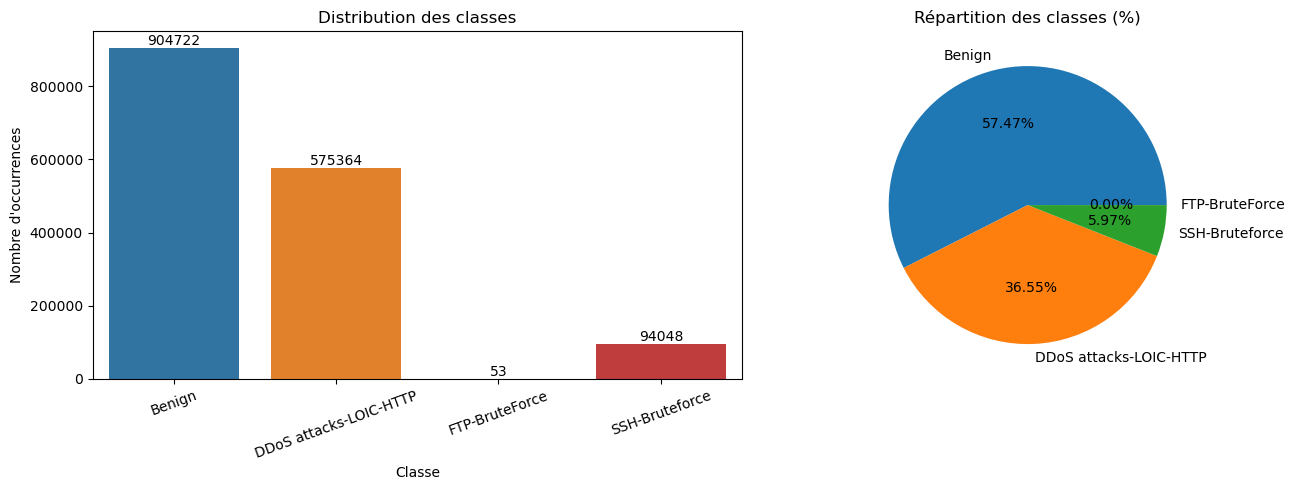

,Classe,Nombre,Pourcentage (%)
0,Benign,904722,57.47
1,DDoS attacks-LOIC-HTTP,575364,36.55
2,SSH-Bruteforce,94048,5.97
3,FTP-BruteForce,53,0.00


In [52]:
class_counts = df['Label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Bar Chart =====
ax = sns.countplot(
    data=df,
    x='Label',
    hue='Label',
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Distribution des classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre d'occurrences")
axes[0].tick_params(axis='x', rotation=20)

for container in ax.containers:
    ax.bar_label(container)

# ===== Pie Chart =====
class_counts.plot(
    kind='pie',
    autopct='%1.2f%%',
    ax=axes[1]
)

axes[1].set_title("Répartition des classes (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



table_classes = pd.DataFrame({
    "Classe": class_counts.index,
    "Nombre": class_counts.values,
    "Pourcentage (%)": class_pct.values
})


table_classes.style.format({
    "Pourcentage (%)": "{:.2f}"
})

### Analyse de la distribution des classes

La distribution des classes du dataset fusionné a été étudiée afin d’évaluer l’équilibre des données avant l’entraînement des modèles de classification. Les résultats montrent que la classe **Benign** est majoritaire avec 904 722 observations (57,47 %), suivie de la classe **DDoS attacks-LOIC-HTTP** avec 575 364 observations (36,55 %). La classe **SSH-Bruteforce** représente 94 048 observations (5,97 %), tandis que la classe **FTP-BruteForce** ne contient que 53 observations.

Le ratio de déséquilibre entre la classe majoritaire et la classe minoritaire est de **17070**, ce qui indique un déséquilibre très important du dataset. Cette situation peut biaiser les modèles d’apprentissage automatique en faveur des classes les plus représentées et réduire leur capacité à détecter correctement les attaques rares. Afin de limiter cet effet, une technique de rééquilibrage des données telle que **SMOTE** sera appliquée lors de la phase de prétraitement.


--
#### Statistiques descriptives des variables clés

In [54]:
key_feats = [c for c in ["Flow Duration", "Total Fwd Packets",
                         "Flow Bytes/s", "Flow Packets/s"]
             if c in df.columns]

desc_stats = df[key_feats].describe().T[["mean", "std", "min", "max"]]

display(desc_stats.round(2))

,mean,std,min,max
Flow Duration,14155685.14,28890328.61,1.00,120000000.0
Total Fwd Packets,63.20,2793.19,1.00,280043.0
Flow Bytes/s,79536.31,1849871.40,0.00,445250000.0
Flow Packets/s,4678.84,69091.43,0.02,4000000.0


### Analyse descriptive des variables clés

Les statistiques descriptives ont été calculées pour quatre caractéristiques importantes du trafic réseau : *Flow Duration*, *Total Fwd Packets*, *Flow Bytes/s* et *Flow Packets/s*.

La durée moyenne des flux (*Flow Duration*) est d’environ 14,16 millions d’unités de temps, avec une valeur maximale atteignant 120 millions. L’écart-type élevé (28,89 millions) indique une forte dispersion des durées de connexion.

Le nombre moyen de paquets envoyés (*Total Fwd Packets*) est de 63,20 paquets, mais certaines connexions atteignent jusqu’à 280 043 paquets. Cette différence importante entre la moyenne et le maximum suggère la présence de flux anormalement volumineux, potentiellement associés à des attaques réseau.

Concernant le débit (*Flow Bytes/s*), la moyenne est de 79 536 octets par seconde, tandis que la valeur maximale atteint 445 250 000 octets par seconde. De même, la variable *Flow Packets/s* présente une moyenne de 4 678 paquets par seconde et un maximum de 4 000 000 paquets par seconde.

Les écarts-types très élevés observés pour l’ensemble des variables montrent une forte variabilité du trafic réseau et indiquent la présence de valeurs extrêmes (outliers). Ces caractéristiques sont cohérentes avec la nature du dataset, qui contient à la fois du trafic normal et plusieurs types d’attaques. Cette analyse confirme l’importance des étapes de prétraitement et de normalisation avant l’entraînement des modèles de détection d’intrusions.


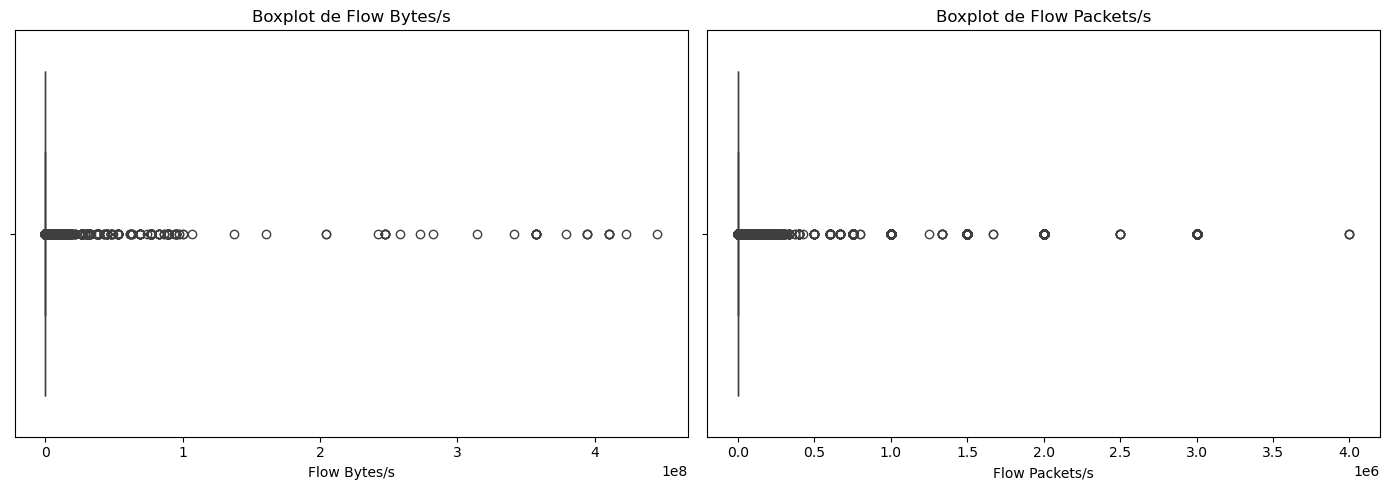

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Flow Bytes/s
sns.boxplot(
    x=df["Flow Bytes/s"],
    ax=axes[0]
)
axes[0].set_title("Boxplot de Flow Bytes/s")

# Boxplot Flow Packets/s
sns.boxplot(
    x=df["Flow Packets/s"],
    ax=axes[1]
)
axes[1].set_title("Boxplot de Flow Packets/s")

plt.tight_layout()
plt.show()

Les boxplots des variables *Flow Bytes/s* et *Flow Packets/s* mettent en évidence la présence de nombreuses valeurs extrêmes. Ces observations correspondent à des flux réseau présentant des débits ou des taux de paquets exceptionnellement élevés. Dans le contexte de la détection d’intrusions, ces valeurs peuvent être associées à des comportements anormaux ou à certains types d’attaques, notamment les attaques par déni de service distribué (DDoS), caractérisées par un volume important de trafic généré en un temps réduit.


## 5. Analyse des correlations
Recherche des paires de features fortement correlees (>0.9), candidates a retirer en feature selection.

In [59]:
num_df = df.select_dtypes(include=[np.number])
sample = num_df.sample(n=min(150000, len(num_df)), random_state=42)
corr = sample.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack()
strong_corr = pairs[pairs > 0.9].sort_values(ascending=False)

print(f"Paires de features avec correlation > 0.9 : {len(strong_corr)}")
strong_corr.head(10)


Paires de features avec correlation > 0.9 : 59


Total Fwd Packets         Subflow Fwd Packets     1.000000
Total Backward Packets    Subflow Bwd Packets     1.000000
Fwd Packets Length Total  Subflow Fwd Bytes       1.000000
Fwd Packet Length Mean    Avg Fwd Segment Size    1.000000
Bwd Packet Length Mean    Avg Bwd Segment Size    1.000000
Bwd Packets Length Total  Subflow Bwd Bytes       1.000000
Fwd PSH Flags             SYN Flag Count          1.000000
RST Flag Count            ECE Flag Count          1.000000
Subflow Fwd Bytes         Fwd Act Data Packets    0.999911
Fwd Packets Length Total  Fwd Act Data Packets    0.999911
dtype: float64

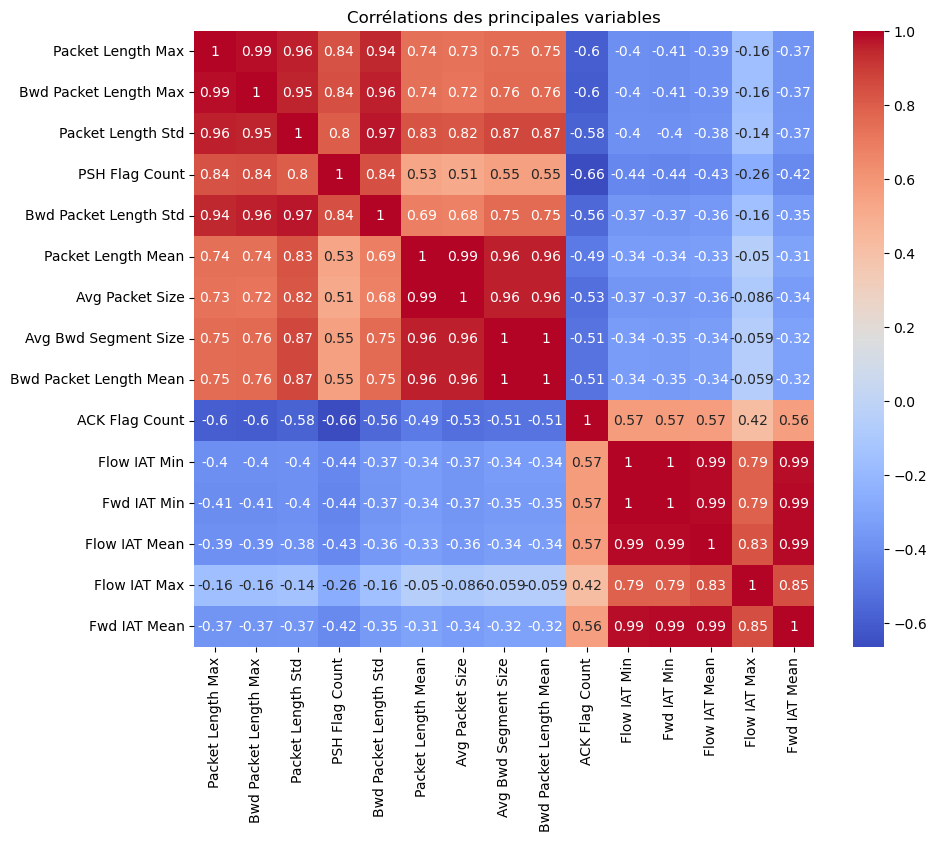

In [60]:
top_feats = num_df.corr().abs().sum().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))
sns.heatmap(
    df[top_feats].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Corrélations des principales variables")
plt.show()

### Analyse des corrélations

Une matrice de corrélation a été calculée sur les variables numériques afin d’identifier les caractéristiques redondantes. Les résultats montrent l’existence de **59 paires de variables présentant une corrélation supérieure à 0,9**, ce qui indique une forte dépendance linéaire entre certaines caractéristiques.

La heatmap met en évidence plusieurs groupes de variables fortement corrélées, notamment *Total Fwd Packets* et *Subflow Fwd Packets*, ainsi que *Packet Length Mean* et *Avg Packet Size*. Ces variables transportent des informations très similaires et peuvent être considérées comme redondantes.

Cette analyse suggère qu’une étape de sélection de variables peut être appliquée afin de réduire la redondance, diminuer la dimension des données et améliorer l’efficacité des modèles de classification tout en conservant l’essentiel de l’information.


In [11]:
# Suggestion de colonnes a retirer (garder une seule feature par paire correlee)
cols_a_retirer = set()
for (f1, f2) in strong_corr.index:
    if f1 not in cols_a_retirer:
        cols_a_retirer.add(f2)
print(f"Suggestion : {len(cols_a_retirer)} colonnes redondantes a retirer")
sorted(cols_a_retirer)


Suggestion : 30 colonnes redondantes a retirer


['Active Min',
 'Avg Bwd Segment Size',
 'Avg Fwd Segment Size',
 'Avg Packet Size',
 'Bwd Header Length',
 'Bwd IAT Max',
 'Bwd Packet Length Std',
 'Bwd Packets Length Total',
 'ECE Flag Count',
 'Flow IAT Min',
 'Fwd Act Data Packets',
 'Fwd Header Length',
 'Fwd IAT Max',
 'Fwd IAT Mean',
 'Fwd IAT Min',
 'Fwd IAT Total',
 'Fwd Packet Length Std',
 'Fwd Packets Length Total',
 'Fwd Packets/s',
 'Idle Max',
 'Idle Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Min',
 'Packet Length Std',
 'SYN Flag Count',
 'Subflow Bwd Bytes',
 'Subflow Bwd Packets',
 'Subflow Fwd Bytes',
 'Subflow Fwd Packets']

--- 
Une analyse des corrélations a permis d’identifier 30 variables redondantes potentielles. Toutefois, ces variables ont été conservées pour l’entraînement des modèles Random Forest et XGBoost, car ces algorithmes sont relativement robustes face à la multicolinéarité. Les résultats de cette analyse restent néanmoins utiles pour une éventuelle étape future de réduction de dimension.

## 6. Detection des outliers (methode IQR)
Attention : sur du trafic reseau, un fort taux d'outliers est normal (les attaques generent des valeurs extremes). Ne pas les supprimer aveuglement.

In [62]:
outlier_summary = {}
for feat in key_feats:
    q1, q3 = df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[feat] < low) | (df[feat] > high)).sum()
    pct_out = 100 * n_out / len(df)
    outlier_summary[feat] = (n_out, pct_out)
    print(f"{feat} : {n_out} outliers ({pct_out:.2f}%)")


Flow Duration : 275853 outliers (17.52%)
Total Fwd Packets : 170660 outliers (10.84%)
Flow Bytes/s : 250653 outliers (15.92%)
Flow Packets/s : 283596 outliers (18.02%)


### Détection des valeurs aberrantes (Outliers)

La méthode IQR (Interquartile Range) a été utilisée pour identifier les valeurs aberrantes dans les principales variables du trafic réseau. Les résultats montrent que 17,52 % des observations de la variable *Flow Duration*, 10,84 % de *Total Fwd Packets*, 15,92 % de *Flow Bytes/s* et 18,02 % de *Flow Packets/s* sont considérées comme des outliers.

La présence d’un nombre important de valeurs extrêmes est cohérente avec la nature du dataset étudié, qui contient à la fois du trafic normal et plusieurs types d’attaques réseau. En particulier, les attaques DDoS génèrent souvent des débits très élevés ainsi qu’un nombre important de paquets par seconde, ce qui explique les fortes proportions d’outliers observées pour les variables *Flow Bytes/s* et *Flow Packets/s*.

Contrairement à d’autres domaines où les valeurs aberrantes sont souvent supprimées, ces observations ont été conservées dans cette étude car elles peuvent représenter des comportements malveillants importants pour la détection d’intrusions.


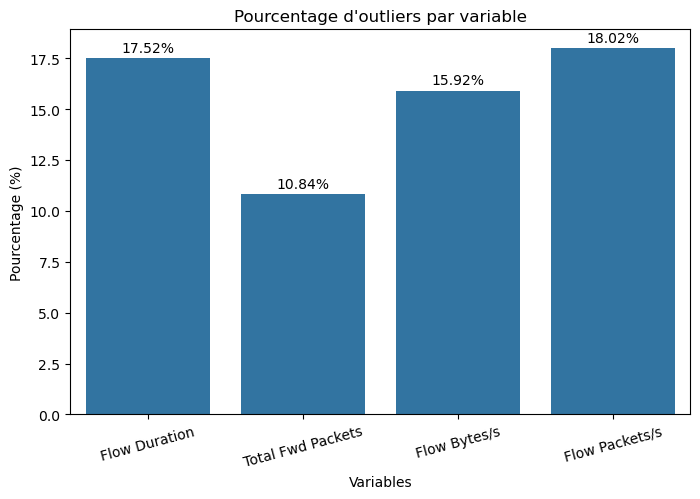

In [64]:
outlier_pct = {
    "Flow Duration": 17.52,
    "Total Fwd Packets": 10.84,
    "Flow Bytes/s": 15.92,
    "Flow Packets/s": 18.02
}

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=list(outlier_pct.keys()),
    y=list(outlier_pct.values())
)

plt.title("Pourcentage d'outliers par variable")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Variables")

for i, v in enumerate(outlier_pct.values()):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.show()

## 7. Visualisations

### 7.1 Distribution des classes

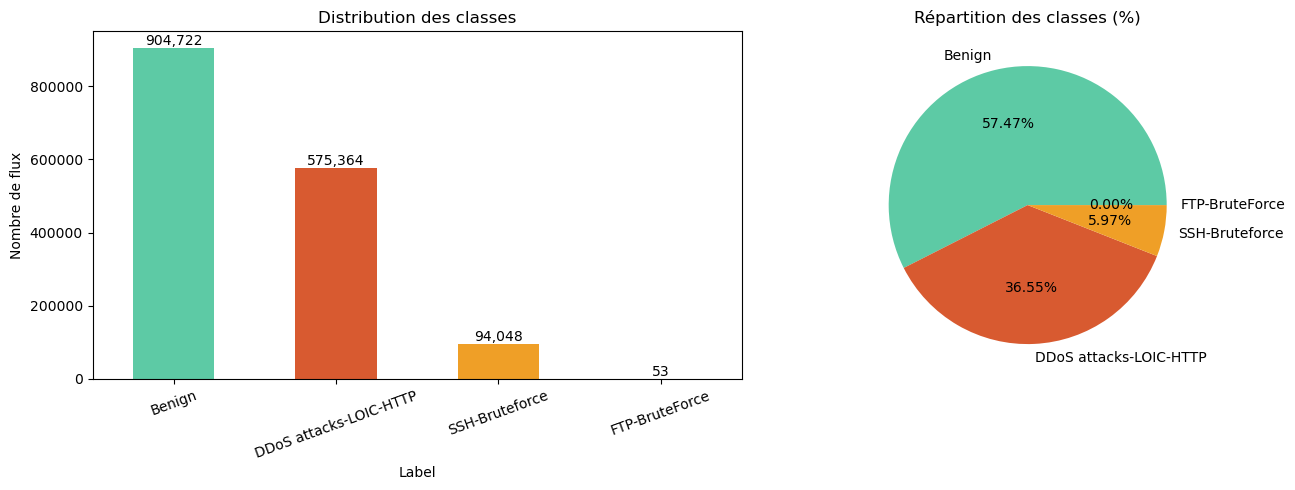

In [70]:
palette = ["#5DCAA5", "#D85A30", "#EF9F27", "#378ADD"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Bar Chart =====
class_counts.plot(
    kind="bar",
    color=palette[:len(class_counts)],
    ax=axes[0]
)

axes[0].set_title("Distribution des classes")
axes[0].set_ylabel("Nombre de flux")
axes[0].tick_params(axis='x', rotation=20)

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom')

# ===== Pie Chart =====
class_counts.plot(
    kind="pie",
    autopct="%1.2f%%",
    colors=palette[:len(class_counts)],
    ax=axes[1]
)

axes[1].set_title("Répartition des classes (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 7.2 Heatmap de correlation (top 15 features par variance)

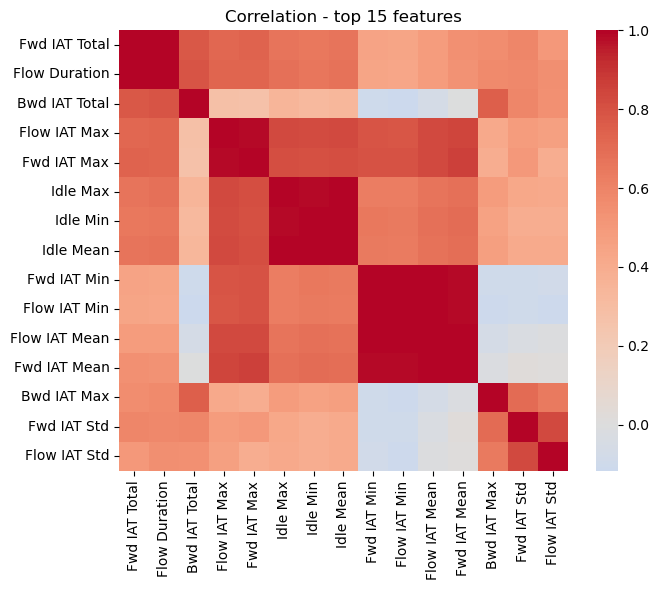

In [66]:
plt.figure(figsize=(7, 6))
top_var_cols = num_df.var().sort_values(ascending=False).head(15).index
sns.heatmap(sample[top_var_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation - top 15 features")
plt.tight_layout()
plt.show()


### Analyse de la matrice de corrélation

La heatmap des 15 variables présentant la plus forte variance met en évidence plusieurs groupes de caractéristiques fortement corrélées. Les variables liées aux temps d’arrivée des paquets (*Flow IAT Mean*, *Flow IAT Min*, *Fwd IAT Mean*, *Fwd IAT Min*) ainsi que les variables d’inactivité (*Idle Max*, *Idle Min*, *Idle Mean*) présentent des coefficients de corrélation élevés, indiquant qu’elles transportent des informations similaires.

La présence de ces corrélations confirme l’existence d’une redondance entre certaines caractéristiques du dataset. Cette observation est cohérente avec les résultats de l’analyse précédente, qui a identifié 59 paires de variables fortement corrélées. Ces informations pourront être exploitées lors de la phase de sélection des caractéristiques afin de réduire la dimension des données sans perte significative d’information.


### 7.3 Flow Duration par classe

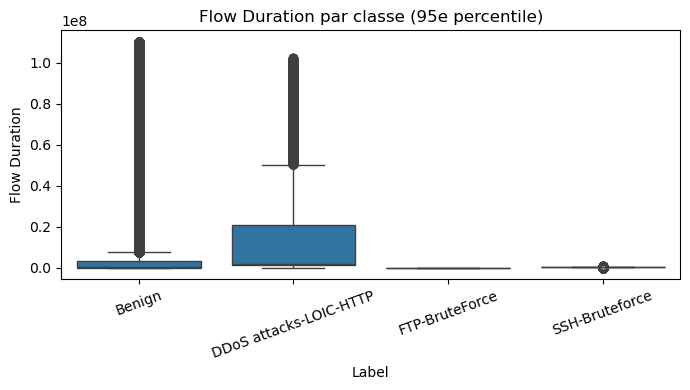

In [71]:
plt.figure(figsize=(7, 4))
sub = df[df["Flow Duration"] < df["Flow Duration"].quantile(0.95)]
sns.boxplot(data=sub, x="Label", y="Flow Duration")
plt.xticks(rotation=20)
plt.title("Flow Duration par classe (95e percentile)")
plt.tight_layout()
plt.show()


### 7.4 Flow Bytes/s par classe

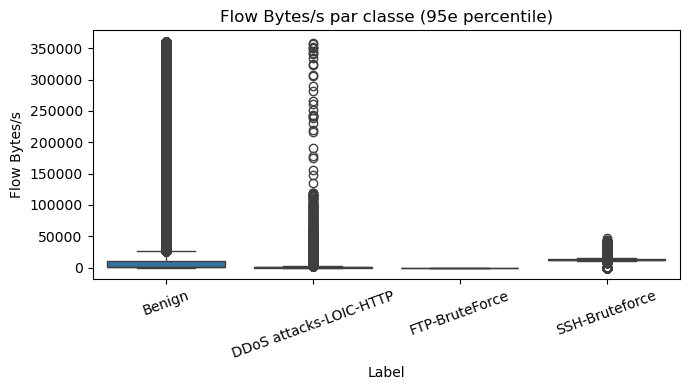

In [72]:
plt.figure(figsize=(7, 4))
sub2 = df[df["Flow Bytes/s"] < df["Flow Bytes/s"].quantile(0.95)]
sns.boxplot(data=sub2, x="Label", y="Flow Bytes/s")
plt.xticks(rotation=20)
plt.title("Flow Bytes/s par classe (95e percentile)")
plt.tight_layout()
plt.show()


### 7.5 Distribution de Total Fwd Packets par classe

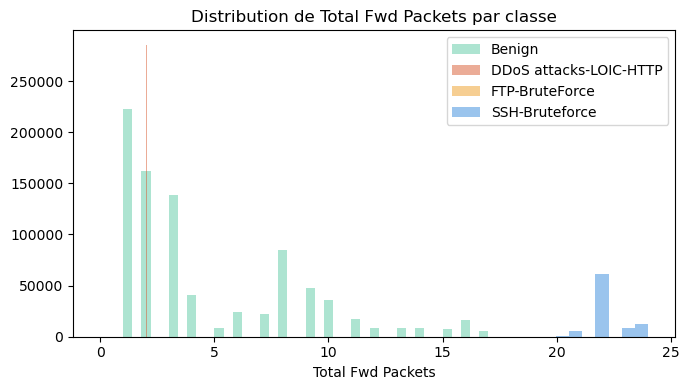

In [73]:
plt.figure(figsize=(7, 4))
for i, lbl in enumerate(df["Label"].unique()):
    vals = df[df["Label"] == lbl]["Total Fwd Packets"]
    vals = vals[vals < vals.quantile(0.95)]
    plt.hist(vals, bins=40, alpha=0.5, label=lbl, color=palette[i % len(palette)])
plt.legend()
plt.title("Distribution de Total Fwd Packets par classe")
plt.xlabel("Total Fwd Packets")
plt.tight_layout()
plt.show()


### 7.6 Pourcentage d'outliers par feature cle

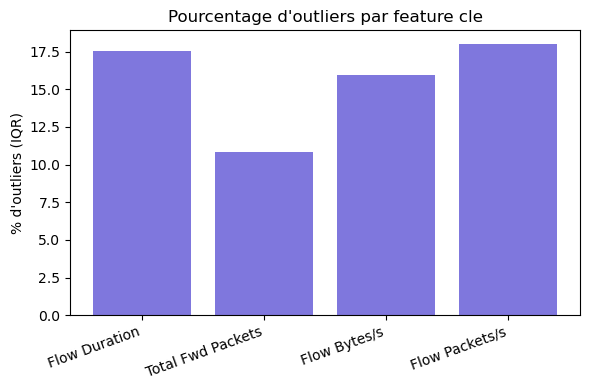

In [74]:
plt.figure(figsize=(6, 4))
feats_names = list(outlier_summary.keys())
pct_values = [outlier_summary[f][1] for f in feats_names]
plt.bar(feats_names, pct_values, color="#7F77DD")
plt.ylabel("% d'outliers (IQR)")
plt.xticks(rotation=20, ha="right")
plt.title("Pourcentage d'outliers par feature cle")
plt.tight_layout()
plt.show()


## 8. Sauvegarde du dataset nettoye
Le dataset nettoye est sauvegarde pour l'etape 2 (feature selection, encodage, scaling).

In [75]:
df.to_parquet(f"{OUTPUT_DIR}/df_clean.parquet")
print(f"Dataset nettoye sauvegarde : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\nEDA TERMINEE - pret pour l'etape 2 (feature selection + encodage + scaling)")


Dataset nettoye sauvegarde : 1574187 lignes, 68 colonnes

EDA TERMINEE - pret pour l'etape 2 (feature selection + encodage + scaling)
